# UGST4012 - Digital Tools for the Social Sciences 
## Central European University, Winter 2020/2021
## LAB 7: Emotional arcs
## February 25th, 2021 
Author: Gabriela Juncosa, PhD

## 0. Outline for class 
In this lab we will: 

    1. Address two issues with last week's code: (1) not removing duplicates, and (2) dataframe indices  
    2. Download more than 20 tweets  
    3. Upload and clean data 
    4. Counting words in corpus
    5. Word count visualization
    6. TF-IDF
    7. Introduction to sentiment analysis 

In [1]:
import tweepy
import json
import os
import re
import pandas as pd
import nltk # NOTE: this is a new library if it doesn't import install it!
nltk.download('wordnet')
nltk.download('averaged_perceptron_tagger')

[nltk_data] Downloading package wordnet to /Users/julieta/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /Users/julieta/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!


True

## 1. Upload datasets  

In [2]:
os.getcwd()

'/usr/local/bin/PhD notebooks GT/UGST4012/LAB7'

In [3]:
# upload data sets, remember to check the directory where you saved them
all_tweets = pd.read_csv(r'VP_KHarris_tweets_all.csv')
sentiment = pd.read_csv(r'EnglishShortened.csv')

In [5]:
all_tweets.head()

,Unnamed: 0,Unnamed: 0.1,ID,text,favoriteCount,retweetCount,createdAt,tweetPunct,tweetToken,tweetLemmas
0,0,0,1354582563164139520,"Congratulations to our new Secretary of State,...",51995,4115,2021-01-28 00:10:24,congratulations to our new secretary of state ...,"['congratulations', 'to', 'our', 'new', 'secre...","['congratulation', 'to', 'our', 'new', 'secret..."
1,1,1,1354557611748765697,"Across the world, climate change poses an exis...",10941,1378,2021-01-27 22:31:15,across the world climate change poses an exist...,"['across', 'the', 'world', 'climate', 'change'...","['across', 'the', 'world', 'climate', 'change'..."
2,2,2,1354510467918667784,"One week on the job: we took action on COVID, ...",58543,4583,2021-01-27 19:23:55,one week on the job we took action on covid th...,"['one', 'week', 'on', 'the', 'job', 'we', 'too...","['one', 'week', 'on', 'the', 'job', 'we', 'too..."
3,3,3,1354489791623159810,RT @POTUS: We have no time to waste when it co...,0,10846,2021-01-27 18:01:46,rt potus we have no time to waste when it come...,"['rt', 'potus', 'we', 'have', 'no', 'time', 't...","['rt', 'potus', 'we', 'have', 'no', 'time', 't..."
4,4,4,1354486618518937609,President Biden and I will continue to stand u...,11215,997,2021-01-27 17:49:09,president biden and i will continue to stand u...,"['president', 'biden', 'and', 'i', 'will', 'co...","['president', 'biden', 'and', 'i', 'will', 'co..."


In [6]:
sentiment.head()

,Word,valence,arousal,dominance
0,aardvark,6.26,2.41,4.27
1,abalone,5.30,2.65,4.95
2,abandon,2.84,3.73,3.32
3,abandonment,2.63,4.95,2.64
4,abbey,5.85,2.20,5.00


## 2. Calculate sentiment for 1 tweet  

In [10]:
# how many words are there in this tweet
test = pd.DataFrame(eval(all_tweets['tweetLemmas'][0]), columns = ['Word'])
print('There are:', test.shape[0], 'words in this tweet')

There are: 16 words in this tweet


In [11]:
test.head(16)

,Word
0,congratulation
1,to
2,our
3,new
4,secretary
5,of
6,state
7,antony
8,blinken
9,secblinken


In [7]:
sentiment.head()

,Word,valence,arousal,dominance
0,aardvark,6.26,2.41,4.27
1,abalone,5.30,2.65,4.95
2,abandon,2.84,3.73,3.32
3,abandonment,2.63,4.95,2.64
4,abbey,5.85,2.20,5.00


In [8]:
# match the words from the sentiment dictionary to what you have in tweet
result = pd.merge(test, sentiment, on="Word")
print(result.shape[0], 'words were matched to sentiment dictionary')

print('Average VALENCE for this tweet is:', round(result[["valence", "arousal", 'dominance']].mean()[0],2))
print('Average AROUSAL for this tweet is:', round(result[["valence", "arousal", 'dominance']].mean()[1],4))
print('Average DOMINANCE for this tweet is:', round(result[["valence", "arousal", 'dominance']].mean()[2],2))

6 words were matched to sentiment dictionary
Average VALENCE for this tweet is: 6.12
Average AROUSAL for this tweet is: 4.4
Average DOMINANCE for this tweet is: 6.04


In [12]:
result.head(6)

,Word,valence,arousal,dominance
0,congratulation,7.30,6.05,6.68
1,new,7.68,5.14,5.22
2,secretary,5.18,3.80,6.68
3,state,5.73,3.29,5.65
4,will,5.32,2.90,6.61
5,diplomacy,5.53,5.22,5.42


## 3. Repeat process for entire dataset   

In [13]:
valence = []
arousal = []
dominance = []

for tweet in list(all_tweets['tweetLemmas']):
    test = pd.DataFrame(eval(tweet), columns = ['Word'])
    result = pd.merge(test, sentiment, on="Word")
    
    # append values to empty lists created above 
    valence.append(round(result[["valence"]].mean(),2))
    arousal.append(round(result[["arousal"]].mean(),2))
    dominance.append(round(result[["dominance"]].mean(),2))

In [23]:
all_tweets['Valence'] = valence
all_tweets['Arousal'] = arousal
all_tweets['Dominance'] = dominance

In [24]:
all_tweets.head()

,Unnamed: 0,Unnamed: 0.1,ID,text,favoriteCount,retweetCount,createdAt,tweetPunct,tweetToken,tweetLemmas,Valence,Arousal,Dominance,VAL_tweet_rolling_avg_three
19,19,19,1353066572634497032,"RT @POTUS: We will get through this, together....",0,10930,2021-01-23 19:46:24,rt potus we will get through this together htt...,"['rt', 'potus', 'we', 'will', 'get', 'through'...","['rt', 'potus', 'we', 'will', 'get', 'through'...",valence 6.12 dtype: float64,arousal 4.4 dtype: float64,dominance 6.04 dtype: float64,NaN
18,18,18,1353087016007839745,"This weekend, don’t forget:\n \n- Wear a mask\...",292162,24027,2021-01-23 21:07:38,this weekend don’t forget\n \n wear a mask\n s...,"['this', 'weekend', 'don’t', 'forget', '', '',...","['this', 'weekend', 'don’t', 'forget', '', '',...",valence 5.63 dtype: float64,arousal 4.18 dtype: float64,dominance 5.19 dtype: float64,NaN
17,17,17,1353352962287034370,RT @WhiteHouse: Please wear a mask. https://t....,0,57810,2021-01-24 14:44:24,rt whitehouse please wear a mask httpstcoaaqlm...,"['rt', 'whitehouse', 'please', 'wear', 'a', 'm...","['rt', 'whitehouse', 'please', 'wear', 'a', 'm...",valence 4.51 dtype: float64,arousal 4.69 dtype: float64,dominance 4.52 dtype: float64,5.720000
16,16,16,1353368375729283073,The beginning of our new journey. https://t.co...,394536,16918,2021-01-24 15:45:39,the beginning of our new journey httpstcoygtjijrf,"['the', 'beginning', 'of', 'our', 'new', 'jour...","['the', 'beginning', 'of', 'our', 'new', 'jour...",valence 5.05 dtype: float64,arousal 4.3 dtype: float64,dominance 5.08 dtype: float64,6.123333
15,15,15,1353757532267962371,"RT @POTUS: Today, I repealed the discriminator...",0,30878,2021-01-25 17:32:01,rt potus today i repealed the discriminatory b...,"['rt', 'potus', 'today', 'i', 'repealed', 'the...","['rt', 'potus', 'today', 'i', 'repealed', 'the...",valence 5.34 dtype: float64,arousal 3.9 dtype: float64,dominance 5.8 dtype: float64,5.926667


In [16]:
all_tweets = all_tweets.sort_values(by = ['createdAt'], ascending = True)

## 4. Plot results  

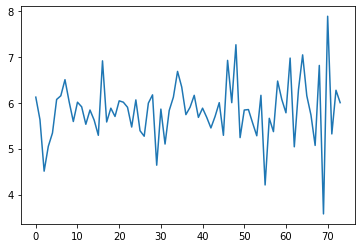

In [19]:
import matplotlib.pyplot as plt
plt.plot(valence)
plt.show()

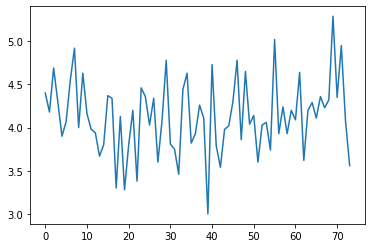

In [17]:
import matplotlib.pyplot as plt
plt.plot(arousal)
plt.show()

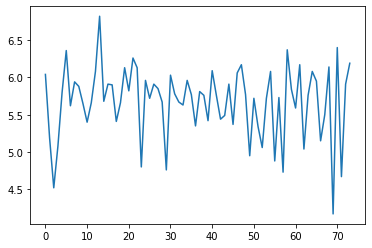

In [18]:
import matplotlib.pyplot as plt
plt.plot(dominance)
plt.show()

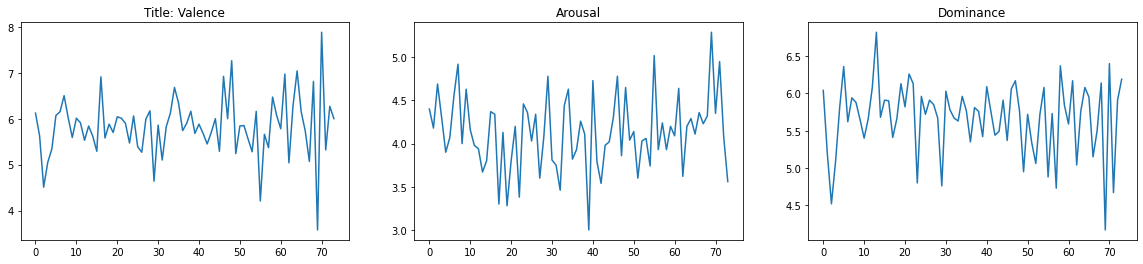

In [20]:
fig, ax = plt.subplots(nrows=1, ncols=3, figsize=(20,4))
ax[0].plot(valence)
ax[0].set_title('Title: Valence')

ax[1].plot(arousal)
ax[1].set_title('Arousal')

ax[2].plot(dominance)
ax[2].set_title('Dominance')

plt.show()

## 4. Rolling average

For reference: https://www.geeksforgeeks.org/how-to-make-a-time-series-plot-with-rolling-average-in-python/

In [21]:
all_tweets['VAL_tweet_rolling_avg_three'] = all_tweets.Valence.rolling(3).mean() 
all_tweets.head(5)

,Unnamed: 0,Unnamed: 0.1,ID,text,favoriteCount,retweetCount,createdAt,tweetPunct,tweetToken,tweetLemmas,Valence,Arousal,Dominance,VAL_tweet_rolling_avg_three
19,19,19,1353066572634497032,"RT @POTUS: We will get through this, together....",0,10930,2021-01-23 19:46:24,rt potus we will get through this together htt...,"['rt', 'potus', 'we', 'will', 'get', 'through'...","['rt', 'potus', 'we', 'will', 'get', 'through'...",valence 5.7 dtype: float64,arousal 3.28 dtype: float64,dominance 6.13 dtype: float64,NaN
18,18,18,1353087016007839745,"This weekend, don’t forget:\n \n- Wear a mask\...",292162,24027,2021-01-23 21:07:38,this weekend don’t forget\n \n wear a mask\n s...,"['this', 'weekend', 'don’t', 'forget', '', '',...","['this', 'weekend', 'don’t', 'forget', '', '',...",valence 5.88 dtype: float64,arousal 4.13 dtype: float64,dominance 5.66 dtype: float64,NaN
17,17,17,1353352962287034370,RT @WhiteHouse: Please wear a mask. https://t....,0,57810,2021-01-24 14:44:24,rt whitehouse please wear a mask httpstcoaaqlm...,"['rt', 'whitehouse', 'please', 'wear', 'a', 'm...","['rt', 'whitehouse', 'please', 'wear', 'a', 'm...",valence 5.58 dtype: float64,arousal 3.3 dtype: float64,dominance 5.41 dtype: float64,5.720000
16,16,16,1353368375729283073,The beginning of our new journey. https://t.co...,394536,16918,2021-01-24 15:45:39,the beginning of our new journey httpstcoygtjijrf,"['the', 'beginning', 'of', 'our', 'new', 'jour...","['the', 'beginning', 'of', 'our', 'new', 'jour...",valence 6.91 dtype: float64,arousal 4.34 dtype: float64,dominance 5.9 dtype: float64,6.123333
15,15,15,1353757532267962371,"RT @POTUS: Today, I repealed the discriminator...",0,30878,2021-01-25 17:32:01,rt potus today i repealed the discriminatory b...,"['rt', 'potus', 'today', 'i', 'repealed', 'the...","['rt', 'potus', 'today', 'i', 'repealed', 'the...",valence 5.29 dtype: float64,arousal 4.37 dtype: float64,dominance 5.91 dtype: float64,5.926667


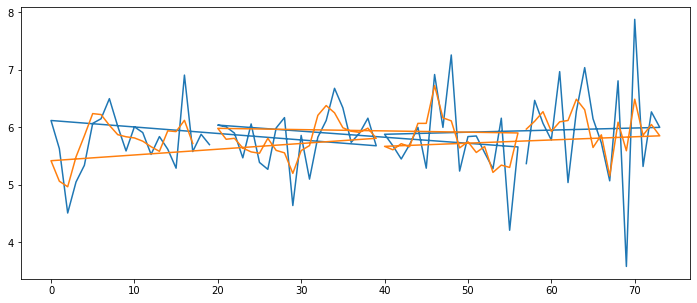

In [22]:
# set figure size 
plt.figure( figsize = ( 12, 5)) 

plt.plot(all_tweets['Valence'], data = all_tweets, label = 'Valence')
plt.plot(all_tweets['VAL_tweet_rolling_avg_three'], data = all_tweets, label = 'Valence')

In [23]:
all_tweets['VAL_tweet_rolling_avg_five'] = all_tweets.Valence.rolling(5).mean() 
all_tweets.head(5)

,Unnamed: 0,Unnamed: 0.1,ID,text,favoriteCount,retweetCount,createdAt,tweetPunct,tweetToken,tweetLemmas,Valence,Arousal,Dominance,VAL_tweet_rolling_avg_three,VAL_tweet_rolling_avg_five
0,0,0,1354582563164139520,"Congratulations to our new Secretary of State,...",51995,4115,2021-01-28 00:10:24,congratulations to our new secretary of state ...,"['congratulations', 'to', 'our', 'new', 'secre...","['congratulation', 'to', 'our', 'new', 'secret...",valence 6.12 dtype: float64,arousal 4.4 dtype: float64,dominance 6.04 dtype: float64,NaN,NaN
1,1,1,1354557611748765697,"Across the world, climate change poses an exis...",10941,1378,2021-01-27 22:31:15,across the world climate change poses an exist...,"['across', 'the', 'world', 'climate', 'change'...","['across', 'the', 'world', 'climate', 'change'...",valence 5.63 dtype: float64,arousal 4.18 dtype: float64,dominance 5.19 dtype: float64,NaN,NaN
2,2,2,1354510467918667784,"One week on the job: we took action on COVID, ...",58543,4583,2021-01-27 19:23:55,one week on the job we took action on covid th...,"['one', 'week', 'on', 'the', 'job', 'we', 'too...","['one', 'week', 'on', 'the', 'job', 'we', 'too...",valence 4.51 dtype: float64,arousal 4.69 dtype: float64,dominance 4.52 dtype: float64,5.420000,NaN
3,3,3,1354489791623159810,RT @POTUS: We have no time to waste when it co...,0,10846,2021-01-27 18:01:46,rt potus we have no time to waste when it come...,"['rt', 'potus', 'we', 'have', 'no', 'time', 't...","['rt', 'potus', 'we', 'have', 'no', 'time', 't...",valence 5.05 dtype: float64,arousal 4.3 dtype: float64,dominance 5.08 dtype: float64,5.063333,NaN
4,4,4,1354486618518937609,President Biden and I will continue to stand u...,11215,997,2021-01-27 17:49:09,president biden and i will continue to stand u...,"['president', 'biden', 'and', 'i', 'will', 'co...","['president', 'biden', 'and', 'i', 'will', 'co...",valence 5.34 dtype: float64,arousal 3.9 dtype: float64,dominance 5.8 dtype: float64,4.966667,5.33


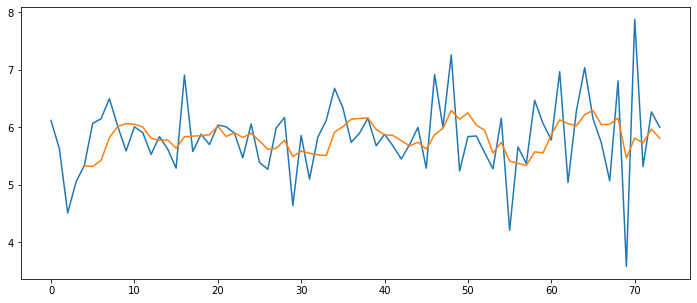

In [57]:
# set figure size 
plt.figure( figsize = ( 12, 5)) 

plt.plot(all_tweets['Valence'], data = all_tweets, label = 'Valence')
plt.plot(all_tweets['VAL_tweet_rolling_avg_five'], data = all_tweets, label = 'Valence')

In [25]:
all_tweets['VAL_tweet_rolling_avg_ten'] = all_tweets.Valence.rolling(10).mean() 
all_tweets.head(5)

,Unnamed: 0,Unnamed: 0.1,ID,text,favoriteCount,retweetCount,createdAt,tweetPunct,tweetToken,tweetLemmas,Valence,Arousal,Dominance,VAL_tweet_rolling_avg_three,VAL_tweet_rolling_avg_five,VAL_tweet_rolling_avg_ten
0,0,0,1354582563164139520,"Congratulations to our new Secretary of State,...",51995,4115,2021-01-28 00:10:24,congratulations to our new secretary of state ...,"['congratulations', 'to', 'our', 'new', 'secre...","['congratulation', 'to', 'our', 'new', 'secret...",valence 6.12 dtype: float64,arousal 4.4 dtype: float64,dominance 6.04 dtype: float64,NaN,NaN,NaN
1,1,1,1354557611748765697,"Across the world, climate change poses an exis...",10941,1378,2021-01-27 22:31:15,across the world climate change poses an exist...,"['across', 'the', 'world', 'climate', 'change'...","['across', 'the', 'world', 'climate', 'change'...",valence 5.63 dtype: float64,arousal 4.18 dtype: float64,dominance 5.19 dtype: float64,NaN,NaN,NaN
2,2,2,1354510467918667784,"One week on the job: we took action on COVID, ...",58543,4583,2021-01-27 19:23:55,one week on the job we took action on covid th...,"['one', 'week', 'on', 'the', 'job', 'we', 'too...","['one', 'week', 'on', 'the', 'job', 'we', 'too...",valence 4.51 dtype: float64,arousal 4.69 dtype: float64,dominance 4.52 dtype: float64,5.420000,NaN,NaN
3,3,3,1354489791623159810,RT @POTUS: We have no time to waste when it co...,0,10846,2021-01-27 18:01:46,rt potus we have no time to waste when it come...,"['rt', 'potus', 'we', 'have', 'no', 'time', 't...","['rt', 'potus', 'we', 'have', 'no', 'time', 't...",valence 5.05 dtype: float64,arousal 4.3 dtype: float64,dominance 5.08 dtype: float64,5.063333,NaN,NaN
4,4,4,1354486618518937609,President Biden and I will continue to stand u...,11215,997,2021-01-27 17:49:09,president biden and i will continue to stand u...,"['president', 'biden', 'and', 'i', 'will', 'co...","['president', 'biden', 'and', 'i', 'will', 'co...",valence 5.34 dtype: float64,arousal 3.9 dtype: float64,dominance 5.8 dtype: float64,4.966667,5.33,NaN


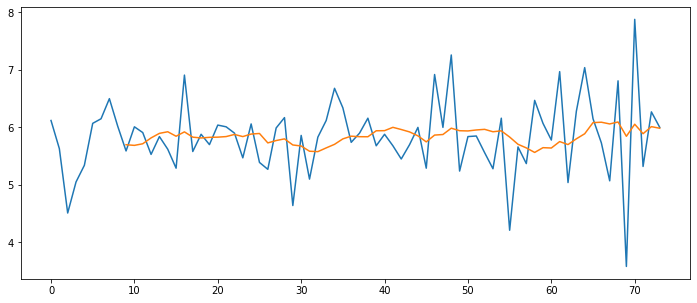

In [26]:
# set figure size 
plt.figure( figsize = ( 12, 5)) 

plt.plot(all_tweets['Valence'], data = all_tweets, label = 'Valence')
plt.plot(all_tweets['VAL_tweet_rolling_avg_ten'], data = all_tweets, label = 'Valence')

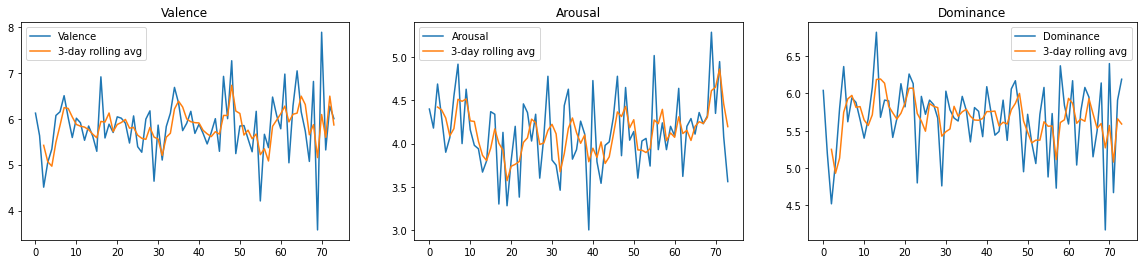

In [27]:
all_tweets['VAL_tweet_rolling_avg_three'] = all_tweets.Valence.rolling(3).mean() 
all_tweets['ARO_tweet_rolling_avg_three'] = all_tweets.Arousal.rolling(3).mean() 
all_tweets['DOM_tweet_rolling_avg_three'] = all_tweets.Dominance.rolling(3).mean() 

fig, ax = plt.subplots(nrows=1, ncols=3, figsize=(20,4))
ax[0].plot(all_tweets['Valence'], data = all_tweets, label = 'Valence')
ax[0].plot(all_tweets['VAL_tweet_rolling_avg_three'], data = all_tweets, label = '3-day rolling avg')
ax[0].set_title('Valence')
ax[0].legend()

ax[1].plot(all_tweets['Arousal'], data = all_tweets, label = 'Arousal')
ax[1].plot(all_tweets['ARO_tweet_rolling_avg_three'], data = all_tweets, label = '3-day rolling avg')
ax[1].set_title('Arousal')
ax[1].legend()

ax[2].plot(all_tweets['Dominance'], data = all_tweets, label = 'Dominance')
ax[2].plot(all_tweets['DOM_tweet_rolling_avg_three'], data = all_tweets, label = '3-day rolling avg')
ax[2].set_title('Dominance')
ax[2].legend()

plt.show()

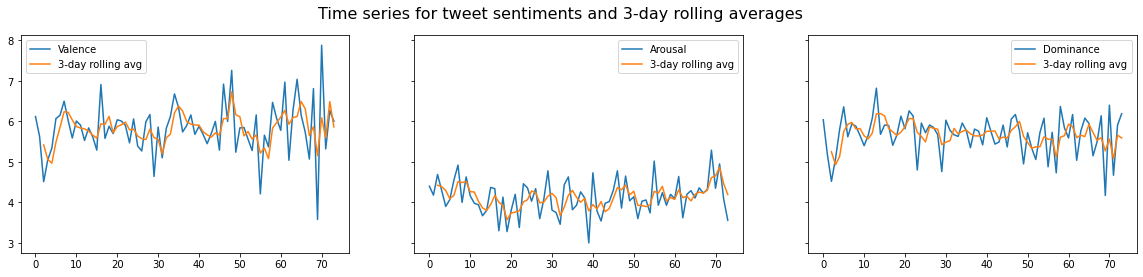

In [28]:
fig, ax = plt.subplots(nrows=1, ncols=3, figsize=(20,4), sharey = True)
fig.suptitle('Time series for tweet sentiments and 3-day rolling averages', fontsize=16)

ax[0].plot(all_tweets['Valence'], data = all_tweets, label = 'Valence')
ax[0].plot(all_tweets['VAL_tweet_rolling_avg_three'], data = all_tweets, label = '3-day rolling avg')
ax[0].legend()

ax[1].plot(all_tweets['Arousal'], data = all_tweets, label = 'Arousal')
ax[1].plot(all_tweets['ARO_tweet_rolling_avg_three'], data = all_tweets, label = '3-day rolling avg')
ax[1].legend()

ax[2].plot(all_tweets['Dominance'], data = all_tweets, label = 'Dominance')
ax[2].plot(all_tweets['DOM_tweet_rolling_avg_three'], data = all_tweets, label = '3-day rolling avg')
ax[2].legend()
plt.show()

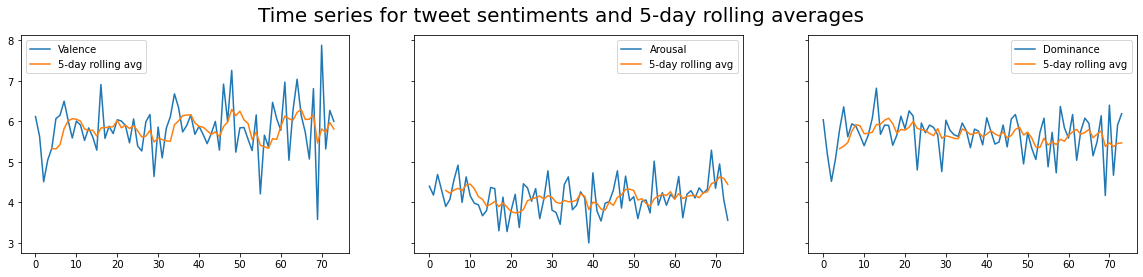

In [29]:
all_tweets['VAL_tweet_rolling_avg_five'] = all_tweets.Valence.rolling(5).mean() 
all_tweets['ARO_tweet_rolling_avg_five'] = all_tweets.Arousal.rolling(5).mean() 
all_tweets['DOM_tweet_rolling_avg_five'] = all_tweets.Dominance.rolling(5).mean() 

fig, ax = plt.subplots(nrows=1, ncols=3, figsize=(20,4), sharey = True)
fig.suptitle('Time series for tweet sentiments and 5-day rolling averages', fontsize=20)

ax[0].plot(all_tweets['Valence'], data = all_tweets, label = 'Valence')
ax[0].plot(all_tweets['VAL_tweet_rolling_avg_five'], data = all_tweets, label = '5-day rolling avg')
ax[0].legend()

ax[1].plot(all_tweets['Arousal'], data = all_tweets, label = 'Arousal')
ax[1].plot(all_tweets['ARO_tweet_rolling_avg_five'], data = all_tweets, label = '5-day rolling avg')
ax[1].legend()

ax[2].plot(all_tweets['Dominance'], data = all_tweets, label = 'Dominance')
ax[2].plot(all_tweets['DOM_tweet_rolling_avg_five'], data = all_tweets, label = '5-day rolling avg')
ax[2].legend()
plt.show()

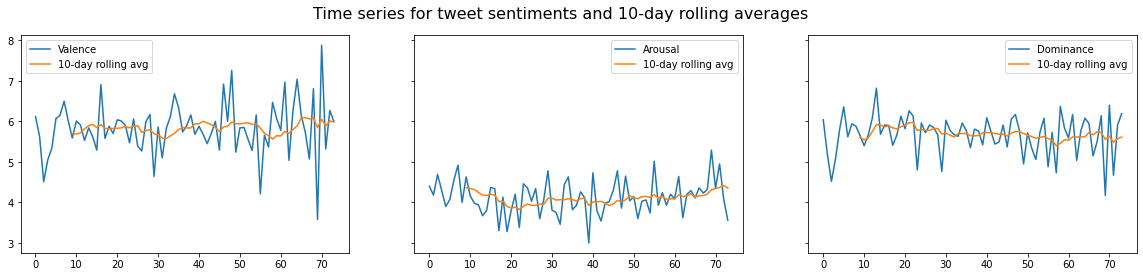

In [81]:
all_tweets['VAL_tweet_rolling_avg_ten'] = all_tweets.Valence.rolling(10).mean() 
all_tweets['ARO_tweet_rolling_avg_ten'] = all_tweets.Arousal.rolling(10).mean() 
all_tweets['DOM_tweet_rolling_avg_ten'] = all_tweets.Dominance.rolling(10).mean() 

fig, ax = plt.subplots(nrows=1, ncols=3, figsize=(20,4), sharey = True)
fig.suptitle('Time series for tweet sentiments and 10-day rolling averages', fontsize=16)

ax[0].plot(all_tweets['Valence'], data = all_tweets, label = 'Valence')
ax[0].plot(all_tweets['VAL_tweet_rolling_avg_ten'], data = all_tweets, label = '10-day rolling avg')
ax[0].legend()

ax[1].plot(all_tweets['Arousal'], data = all_tweets, label = 'Arousal')
ax[1].plot(all_tweets['ARO_tweet_rolling_avg_ten'], data = all_tweets, label = '10-day rolling avg')
ax[1].legend()

ax[2].plot(all_tweets['Dominance'], data = all_tweets, label = 'Dominance')
ax[2].plot(all_tweets['DOM_tweet_rolling_avg_ten'], data = all_tweets, label = '10-day rolling avg')
ax[2].legend()
plt.show()